# Trabalho Prático: Deep Learning para Previsão de Séries Temporais Financeiras
**Curso:** Ciência de Dados e Machine Learning - 5º Semestre (CEUB)

## 1. Introdução e Objetivo
Este projeto foca na construção de um modelo preditivo utilizando redes neurais recorrentes (arquitetura híbrida de LSTM e GRU) no PyTorch. O objetivo é prever o preço de fechamento da ação da Petrobras (PETR4.SA).

Em vez de utilizar apenas o histórico da própria ação (modelo univariado), adotamos uma abordagem multivariada. Foram incluídas a cotação do Dólar (BRL=X) e o preço do barril de Petróleo Brent (BZ=F) para fornecer contexto macroeconômico ao modelo e melhorar a sua capacidade de generalização.

## 2. Coleta e Preparação de Dados
Os dados foram extraídos via API do Yahoo Finance (`yfinance`). Realizamos uma etapa de *feature engineering* para converter o valor do barril de petróleo (cotado em USD) para Reais (BRL), alinhando a escala da moeda com a cotação da PETR4.

In [9]:
import yfinance as yf
import pandas as pd

# Definindo os tickers para a análise multivariada
tickers = ["PETR4.SA", "BZ=F", "BRL=X"]

# Extraindo apenas a coluna 'Close' (Fechamento) para reduzir dimensionalidade
df_bruto = yf.download(tickers, start="2015-01-01", end="2026-01-01")['Close']

# Renomeando as colunas
df_bruto.columns = ['Dolar', 'Petroleo_Brent', 'Petrobras_PETR4']

# Removendo dados nulos (feriados e dias sem negociação em bolsas distintas)
df = df_bruto.dropna()

print("Amostra dos dados carregados:")
display(df.head())

/tmp/ipykernel_12761/1701966160.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bruto = yf.download(tickers, start="2015-01-01", end="2026-01-01")['Close']
[*********************100%***********************]  3 of 3 completed

Amostra dos dados carregados:


,Dolar,Petroleo_Brent,Petrobras_PETR4
Date,,,
2015-01-02,2.6532,56.419998,2.493751
2015-01-05,2.6912,53.110001,2.280610
2015-01-06,2.7031,51.099998,2.206012
2015-01-07,2.6966,51.150002,2.309917
2015-01-08,2.6808,50.959999,2.459116


In [10]:
# Feature Engineering: Convertendo o preço do Petróleo (USD) para BRL
df['Petroleo_em_Real'] = df['Petroleo_Brent'] * df['Dolar']

# Removendo a coluna original em dólar
df = df.drop(columns=['Petroleo_Brent']).copy()

# Reorganizando a ordem do dataframe
df = df[['Dolar', 'Petroleo_em_Real', 'Petrobras_PETR4']]

print("Dataset atualizado com conversão cambial:")
display(df.head())

Dataset atualizado com conversão cambial:


/tmp/ipykernel_12761/74111419.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Petroleo_em_Real'] = df['Petroleo_Brent'] * df['Dolar']


,Dolar,Petroleo_em_Real,Petrobras_PETR4
Date,,,
2015-01-02,2.6532,149.693534,2.493751
2015-01-05,2.6912,142.929635,2.280610
2015-01-06,2.7031,138.128404,2.206012
2015-01-07,2.6966,137.931092,2.309917
2015-01-08,2.6808,136.613564,2.459116


## 3. Separação de Treino e Teste
Para garantir uma avaliação realista, os dados foram isolados cronologicamente. O modelo treinará com o histórico de 2015 a 2024 e será testado contra os dados de 2025.

In [11]:
# Divisão cronológica dos dados (Train-Test Split)
dados_treino = df[df.index < '2025-01-01'].copy()
dados_teste = df[(df.index >= '2025-01-01') & (df.index < '2026-01-01')].copy()

print(f"Amostras de Treino (2015-2024): {len(dados_treino)} dias de pregão")
print(f"Amostras de Teste (2025): {len(dados_teste)} dias de pregão")

Amostras de Treino (2015-2024): 2419 dias de pregão
Amostras de Teste (2025): 245 dias de pregão


## 4. Escalonamento e Criação de Janelas Temporais
Redes neurais são sensíveis à escala dos dados. Utilizamos o `MinMaxScaler` estritamente nos dados de treino para evitar vazamento de dados (*data leakage*). As séries foram formatadas em matrizes com janelas (*timesteps*) de 60 dias.

In [12]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit e transform apenas nos dados de treino
treino_scaled = scaler.fit_transform(dados_treino)
teste_scaled = scaler.transform(dados_teste)

import torch
def create_sequences(data, seq_length):
    X, y = [], []
    target_col_index = 2 # O target é a PETR4

    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length, target_col_index])

    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(treino_scaled, seq_length)
X_test, y_test = create_sequences(teste_scaled, seq_length)

# Conversão para tensores do PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"Shape de entrada X_train: {X_train_tensor.shape}")

Shape de entrada X_train: torch.Size([2359, 60, 3])


## 5. Definição da Arquitetura do Modelo
O modelo empilha uma camada LSTM (para capturar dependências de longo prazo) e uma camada GRU (para refinar o estado de forma computacionalmente mais leve), finalizando com uma camada densa Linear.

In [13]:
import random
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Fixando a semente para garantir reprodutibilidade dos pesos iniciais
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Criação dos DataLoaders (Batches)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_lstm=64, hidden_gru=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_lstm, batch_first=True)
        self.gru = nn.GRU(input_size=hidden_lstm, hidden_size=hidden_gru, batch_first=True)
        self.fc = nn.Linear(hidden_gru, 1)

    def forward(self, x):
        out_lstm, _ = self.lstm(x)
        out_gru, _ = self.gru(out_lstm)
        final_output = self.fc(out_gru[:, -1, :])
        return final_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTM_GRU_Model(input_size=3).to(device)
print(f"Modelo instanciado no dispositivo: {device}")

Modelo instanciado no dispositivo: cuda


## 6. Treinamento e Avaliação do Modelo
Otimização realizada via Adam Optimizer, minimizando o Erro Quadrático Médio (MSE).

Iniciando o treinamento do modelo multivariado...
Época [10/50] | Loss (MSE): 0.00022
Época [20/50] | Loss (MSE): 0.00016
Época [30/50] | Loss (MSE): 0.00016
Época [40/50] | Loss (MSE): 0.00013
Época [50/50] | Loss (MSE): 0.00012


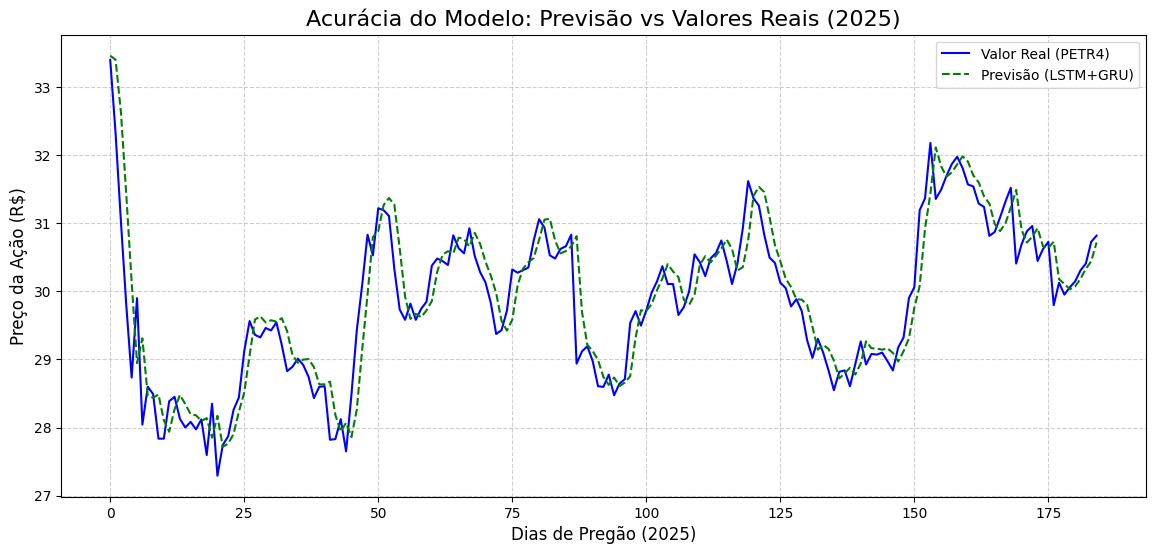

In [14]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

print("Iniciando o treinamento do modelo multivariado...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{epochs}] | Loss (MSE): {avg_loss:.5f}")

# Avaliação no conjunto de teste (2025)
model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    previsoes_escala = model(X_test_tensor).cpu().numpy()

# Transformação inversa para valores reais
matriz_falsa = np.zeros((len(previsoes_escala), 3))
matriz_falsa[:, 2] = previsoes_escala.flatten()
previsoes_reais = scaler.inverse_transform(matriz_falsa)[:, 2]

matriz_falsa_reais = np.zeros((len(y_test), 3))
matriz_falsa_reais[:, 2] = y_test.flatten()
valores_reais_2025 = scaler.inverse_transform(matriz_falsa_reais)[:, 2]

plt.figure(figsize=(14, 6))
plt.plot(valores_reais_2025, color='blue', label='Valor Real (PETR4)')
plt.plot(previsoes_reais, color='green', linestyle='dashed', label='Previsão (LSTM+GRU)')
plt.title('Acurácia do Modelo: Previsão vs Valores Reais (2025)', fontsize=16)
plt.xlabel('Dias de Pregão (2025)', fontsize=12)
plt.ylabel('Preço da Ação (R$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 7. Estudo de Ablação (Ablation Study)
Para comprovar a eficácia das variáveis de contexto, realizou-se o treinamento de um modelo idêntico em arquitetura, porém alimentado unicamente pelos dados da própria PETR4 (Modelo Univariado). O objetivo é isolar e observar o impacto preditivo do Dólar e do Petróleo.

Iniciando treinamento do modelo univariado (Ablation Study)...


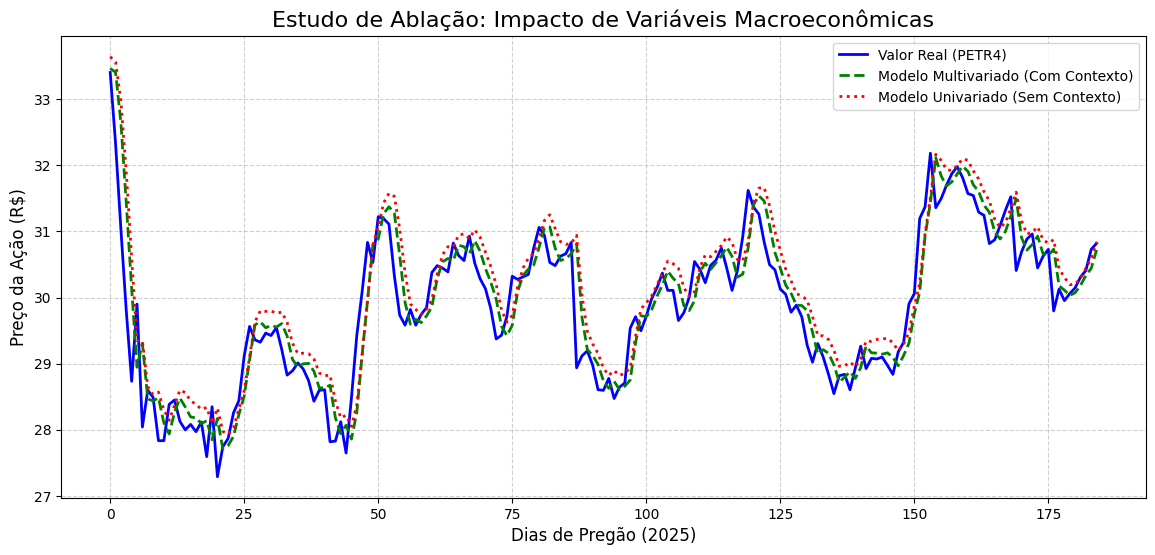

In [15]:
print("Iniciando treinamento do modelo univariado (Ablation Study)...")

df_uni = df[['Petrobras_PETR4']].copy()
treino_uni = df_uni[df_uni.index < '2025-01-01']
teste_uni = df_uni[(df_uni.index >= '2025-01-01') & (df_uni.index < '2026-01-01')]

scaler_uni = MinMaxScaler(feature_range=(0, 1))
treino_scaled_uni = scaler_uni.fit_transform(treino_uni)
teste_scaled_uni = scaler_uni.transform(teste_uni)

def create_seq_uni(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

X_train_u, y_train_u = create_seq_uni(treino_scaled_uni, 60)
X_test_u, y_test_u = create_seq_uni(teste_scaled_uni, 60)

X_train_u_tensor = torch.tensor(X_train_u, dtype=torch.float32)
y_train_u_tensor = torch.tensor(y_train_u, dtype=torch.float32).unsqueeze(1)
X_test_u_tensor = torch.tensor(X_test_u, dtype=torch.float32)

train_loader_u = DataLoader(TensorDataset(X_train_u_tensor, y_train_u_tensor), batch_size=32, shuffle=True)

model_uni = LSTM_GRU_Model(input_size=1).to(device)
optimizer_u = optim.Adam(model_uni.parameters(), lr=0.001)

for epoch in range(epochs):
    model_uni.train()
    for X_batch, y_batch in train_loader_u:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_u.zero_grad()
        predictions = model_uni(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer_u.step()

model_uni.eval()
with torch.no_grad():
    X_test_u_tensor = X_test_u_tensor.to(device)
    previsoes_escala_u = model_uni(X_test_u_tensor).cpu().numpy()

previsoes_reais_uni = scaler_uni.inverse_transform(previsoes_escala_u).flatten()

plt.figure(figsize=(14, 6))
plt.plot(valores_reais_2025, color='blue', linewidth=2, label='Valor Real (PETR4)')
plt.plot(previsoes_reais, color='green', linestyle='dashed', linewidth=2, label='Modelo Multivariado (Com Contexto)')
plt.plot(previsoes_reais_uni, color='red', linestyle='dotted', linewidth=2, label='Modelo Univariado (Sem Contexto)')
plt.title('Estudo de Ablação: Impacto de Variáveis Macroeconômicas', fontsize=16)
plt.xlabel('Dias de Pregão (2025)', fontsize=12)
plt.ylabel('Preço da Ação (R$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 8. Teste de Estresse: O Crash da Pandemia (2020)
Modelos de *Machine Learning* baseados em séries temporais costumam demonstrar vulnerabilidade a anomalias severas no mercado. Nesta etapa final, o modelo é re-treinado com dados até o final de 2019 e submetido ao choque financeiro imprevisível ocorrido em março de 2020.

Iniciando teste de estresse (Crash de 2020)...


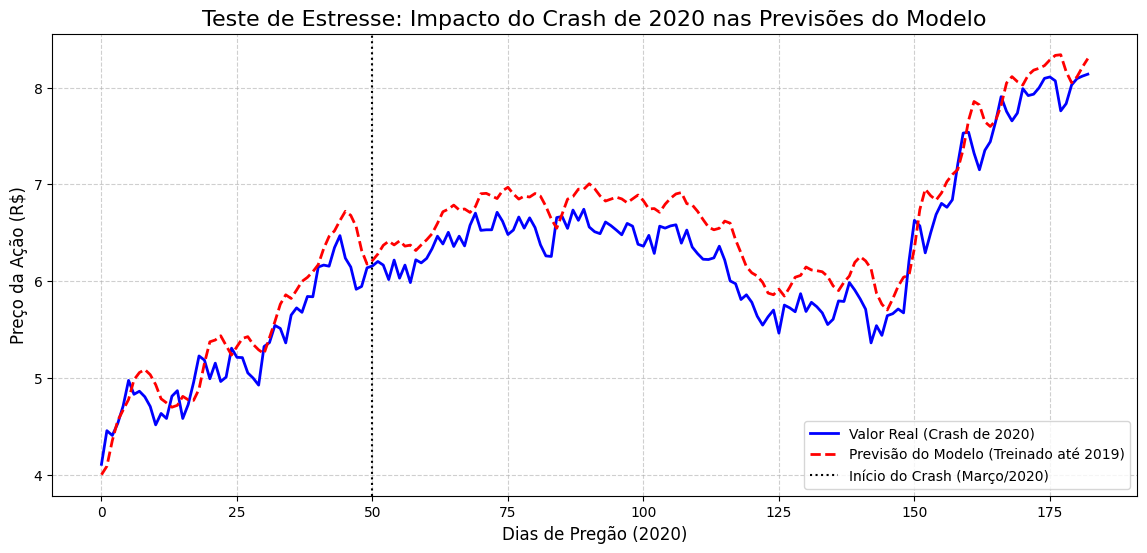

In [16]:
print("Iniciando teste de estresse (Crash de 2020)...")

treino_covid = df[df.index < '2020-01-01'].copy()
teste_covid = df[(df.index >= '2020-01-01') & (df.index < '2021-01-01')].copy()

scaler_covid = MinMaxScaler(feature_range=(0, 1))
treino_scaled_covid = scaler_covid.fit_transform(treino_covid)
teste_scaled_covid = scaler_covid.transform(teste_covid)

X_train_c, y_train_c = create_sequences(treino_scaled_covid, 60)
X_test_c, y_test_c = create_sequences(teste_scaled_covid, 60)

X_train_c_tensor = torch.tensor(X_train_c, dtype=torch.float32)
y_train_c_tensor = torch.tensor(y_train_c, dtype=torch.float32).unsqueeze(1)
X_test_c_tensor = torch.tensor(X_test_c, dtype=torch.float32)

train_loader_covid = DataLoader(TensorDataset(X_train_c_tensor, y_train_c_tensor), batch_size=32, shuffle=True)

model_covid = LSTM_GRU_Model(input_size=3).to(device)
optimizer_c = optim.Adam(model_covid.parameters(), lr=0.001)

for epoch in range(epochs):
    model_covid.train()
    for X_batch, y_batch in train_loader_covid:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_c.zero_grad()
        predictions = model_covid(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer_c.step()

model_covid.eval()
with torch.no_grad():
    X_test_c_tensor = X_test_c_tensor.to(device)
    previsoes_escala_c = model_covid(X_test_c_tensor).cpu().numpy()

matriz_falsa_c = np.zeros((len(previsoes_escala_c), 3))
matriz_falsa_c[:, 2] = previsoes_escala_c.flatten()
previsoes_reais_covid = scaler_covid.inverse_transform(matriz_falsa_c)[:, 2]

matriz_falsa_real_c = np.zeros((len(y_test_c), 3))
matriz_falsa_real_c[:, 2] = y_test_c.flatten()
valores_reais_2020 = scaler_covid.inverse_transform(matriz_falsa_real_c)[:, 2]

plt.figure(figsize=(14, 6))
plt.plot(valores_reais_2020, color='blue', linewidth=2, label='Valor Real (Crash de 2020)')
plt.plot(previsoes_reais_covid, color='red', linestyle='dashed', linewidth=2, label='Previsão do Modelo (Treinado até 2019)')
plt.axvline(x=50, color='black', linestyle=':', label='Início do Crash (Março/2020)')

plt.title('Teste de Estresse: Impacto do Crash de 2020 nas Previsões do Modelo', fontsize=16)
plt.xlabel('Dias de Pregão (2020)', fontsize=12)
plt.ylabel('Preço da Ação (R$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()